# Fine-Tuning TabICL on Imbalanced Classification: SFT vs DPO

This notebook demonstrates how to fine-tune **TabICL** on a **strongly imbalanced** 3-class synthetic
dataset.  We compare the following fine-tuning configurations:

| Run | Loss function | Negative-sampling strategy |
|---|---|---|
| **SFT** | Cross-entropy | — |
| **DPO-random** | DPO | Uniformly random wrong class |
| **DPO-majority** | DPO | Always the majority class (class 2) |
| **DPO-hard** | DPO | Highest-probability wrong class from the frozen reference model |
| **DPO-confusion** | DPO | Most historically confused class (confusion-matrix pass) |

---

## Why DPO for Imbalanced Classification?

Standard supervised fine-tuning (SFT) with cross-entropy optimises the log-likelihood
of the correct class.  On a dataset where 90 % of samples belong to class 2, the model
can achieve misleadingly high *accuracy* simply by always predicting class 2, while
completely ignoring the two minority classes.

**Direct Preference Optimisation (DPO)** augments each training step with an explicit
*rejected* (negative) label.  The DPO loss penalises the trainable model for assigning 
high probability to the rejected class *relative to the reference*, providing a targeted 
signal to pull probability mass away from specific wrong predictions.  

Combined with minority-aware negative-sampling strategies, we hope that this can improve precision, recall, and F1 on the under-represented classes.

--- 
## Installation

Using uv to install the package and finetuning dependencies

In [ ]:
!uv venv --python 3.12
!source .venv/bin/activate
!uv sync
!uv sync --extra finetune

---
## Configuration

All hyperparameters are defined here. They are interpolated into the CLI commands in the cells below.

In [ ]:
# ── Dataset ─────────────────────────────────────────────────────────────────
N_SAMPLES            = 2000
N_CLASSES            = 3
N_FEATURES           = 10
N_INFORMATIVE        = 4
WEIGHTS              = [0.05, 0.05, 0.9]   # strongly imbalanced
DATASET_RANDOM_STATE = 0

# ── Splits ──────────────────────────────────────────────────────────────────
VAL_SIZE  = 0.15
TEST_SIZE = 0.15

# ── Training ────────────────────────────────────────────────────────────────
EPOCHS           = 5
BATCH_SIZE       = 32
CONTEXT_FRACTION = 0.7
LR               = 1e-5
WEIGHT_DECAY     = 0.0
GRADIENT_CLIP    = 1.0
SEED             = 42
LOG_EVERY        = 5
VAL_EVERY        = 1

# ── DPO ─────────────────────────────────────────────────────────────────────
BETA = 0.1   # temperature 

# ── Output ──────────────────────────────────────────────────────────────────
RUNS_DIR     = 'runs/demo'
DATASET_PATH = f'{RUNS_DIR}/dataset.npz'

# ── Pre-build CLI argument strings ────────────────────────────────────────────
WEIGHTS_STR = ' '.join(str(w) for w in WEIGHTS)

# Arguments for make_data.py — controls dataset generation
MAKE_DATA_ARGS = (
    f'--n-samples {N_SAMPLES} --n-classes {N_CLASSES} '
    f'--n-features {N_FEATURES} --n-informative {N_INFORMATIVE} '
    f'--weights {WEIGHTS_STR} '
    f'--dataset-random-state {DATASET_RANDOM_STATE} '
    f'--val-size {VAL_SIZE} --test-size {TEST_SIZE} '
    f'--seed {SEED} '
    f'--output-path {DATASET_PATH}'
)

# Arguments shared by sft.py and dpo.py — dataset loaded from disk
COMMON_ARGS = (
    f'--dataset-path {DATASET_PATH} '
    f'--epochs {EPOCHS} --lr {LR} --batch-size {BATCH_SIZE} '
    f'--context-fraction {CONTEXT_FRACTION} --weight-decay {WEIGHT_DECAY} '
    f'--gradient-clip {GRADIENT_CLIP} --seed {SEED} '
    f'--val-size {VAL_SIZE} --test-size {TEST_SIZE} '
    f'--log-every {LOG_EVERY} --val-every {VAL_EVERY} '
    f'--save-ckpt'
)
print('make_data CLI arguments:')
print(MAKE_DATA_ARGS)
print()
print('Shared training CLI arguments:')
print(COMMON_ARGS)

make_data CLI arguments:
--n-samples 2000 --n-classes 3 --n-features 10 --n-informative 4 --weights 0.05 0.05 0.9 --dataset-random-state 0 --val-size 0.15 --test-size 0.15 --seed 42 --output-path runs/demo/dataset.npz

Shared training CLI arguments:
--dataset-path runs/demo/dataset.npz --epochs 5 --lr 1e-05 --batch-size 32 --context-fraction 0.7 --weight-decay 0.0 --gradient-clip 1.0 --seed 42 --val-size 0.15 --test-size 0.15 --log-every 5 --val-every 1 --save-ckpt


---
## 1. Generate Dataset

We use a controlled environment to generate synthetic imbalanced data using sklearn:

```python
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=cfg.n_samples,
    n_classes=cfg.n_classes,
    n_features=cfg.n_features,
    n_informative=cfg.n_informative,
    weights=cfg.weights,
    random_state=cfg.dataset_random_state,
)
```

In [6]:
import os
os.makedirs(RUNS_DIR, exist_ok=True)

make_data_cmd = f'uv run python -m tabicl.finetune.make_data {MAKE_DATA_ARGS}'
print(make_data_cmd)
!{make_data_cmd}

uv run python -m tabicl.finetune.make_data --n-samples 2000 --n-classes 3 --n-features 10 --n-informative 4 --weights 0.05 0.05 0.9 --dataset-random-state 0 --val-size 0.15 --test-size 0.15 --seed 42 --output-path runs/demo/dataset.npz


Dataset splits — train: 1400, val: 300, test: 300
Classes: [0 1 2]  weights=[0.05, 0.05, 0.9]
Dataset saved to: runs/demo/dataset.npz


---
## 2. Supervised Fine-Tuning (SFT)

SFT fine-tunes TabICL with standard **cross-entropy** loss computed on the query
samples of random context/query chunks sampled from the training dataset.  

In [7]:
sft_cmd = (
    f'uv run python -m tabicl.finetune.sft {COMMON_ARGS} '
    f'--output-dir {RUNS_DIR}/sft'
)
print(sft_cmd)
!{sft_cmd}

uv run python -m tabicl.finetune.sft --dataset-path runs/demo/dataset.npz --epochs 5 --lr 1e-05 --batch-size 32 --context-fraction 0.7 --weight-decay 0.0 --gradient-clip 1.0 --seed 42 --val-size 0.15 --test-size 0.15 --log-every 5 --val-every 1 --save-ckpt --output-dir runs/demo/sft
Device : cuda
Output : runs/demo/sft

Loading dataset from disk: runs/demo/dataset.npz
Loading checkpoint: /mnt/data_2/huggingface/hub/models--jingang--TabICL/snapshots/4dcd344ece2c00be9e831fdd35bed57b5ad83e19/tabicl-classifier-v2-20260212.ckpt
Parameters: 27,552,250 trainable / 27,552,258 total

Epoch   1/5 — train loss: 0.1022, acc: 0.9700, prec: 0.9323, rec: 0.8508, f1: 0.8859Classification report:
               precision    recall  f1-score   support

           0       0.53      0.56      0.55        16
           1       0.58      0.44      0.50        16
           2       0.94      0.95      0.95       268

    accuracy                           0.90       300
   macro avg       0.68      0.65     

---
## 3. Direct Preference Optimisation (DPO)

DPO replaces cross-entropy with a **preference-ranking loss**.  For each query sample
the model is given:

- **Chosen** (positive) label → the ground-truth class
- **Rejected** (negative) label → a wrong class chosen by the negative-sampling strategy

The DPO loss with temperature β then maximises:

$$\mathcal{L}_{\mathrm{DPO}} = -\log\sigma\!\left(\beta\cdot\bigl[(\log\pi_\theta(y^+|x) - \log\pi_\theta(y^-|x)) - (\log\pi_{\mathrm{ref}}(y^+|x) - \log\pi_{\mathrm{ref}}(y^-|x))\bigr]\right)$$

where $\pi_\theta$ is the trainable model and $\pi_{\mathrm{ref}}$ is the **frozen**
pretrained checkpoint.  This simultaneously pushes probability toward the correct class
and *away from* the rejected class, relative to what the reference model already knows.

We compare **four negative-sampling strategies**:

| Strategy | Description |
|---|---|
| `random` | Uniformly random wrong class, baseline |
| `majority` | Always the majority class (class 2, weight 90 %), directly penalises majority-class bias |
| `hard` | Highest-probability wrong class from the reference model |
| `confusion` | Most historically confused class per true label |


### 2.1 DPO — Random Negative Sampling

The simplest DPO baseline: for each query sample we pick a **uniformly random**
incorrect class as the rejected label.

In [8]:
dpo_random_cmd = (
    f'uv run python -m tabicl.finetune.dpo {COMMON_ARGS} '
    f'--beta {BETA} --preference-generator random '
    f'--output-dir {RUNS_DIR}/dpo_random'
)
print(dpo_random_cmd)
!{dpo_random_cmd}

uv run python -m tabicl.finetune.dpo --dataset-path runs/demo/dataset.npz --epochs 5 --lr 1e-05 --batch-size 32 --context-fraction 0.7 --weight-decay 0.0 --gradient-clip 1.0 --seed 42 --val-size 0.15 --test-size 0.15 --log-every 5 --val-every 1 --save-ckpt --beta 0.1 --preference-generator random --output-dir runs/demo/dpo_random
Device : cuda
Output : runs/demo/dpo_random

Loading dataset from disk: runs/demo/dataset.npz
Loading checkpoint: /mnt/data_2/huggingface/hub/models--jingang--TabICL/snapshots/4dcd344ece2c00be9e831fdd35bed57b5ad83e19/tabicl-classifier-v2-20260212.ckpt
Parameters : 27,552,250 trainable / 27,552,258 total

Preference generator : 'random'
Epoch   1/5 — train dpo_loss: 0.3891, acc: 0.9496, prec: 0.9204, rec: 0.7205, f1: 0.7933Classification report:
               precision    recall  f1-score   support

           0       0.71      0.62      0.67        16
           1       1.00      0.25      0.40        16
           2       0.94      0.99      0.96       268



### 2.2 DPO — Majority Class as Negative

This strategy always sets the rejected label to the **majority class** (class 2,
weight ≈ 90 %).  Every gradient step explicitly penalises the model for predicting
the dominant class, directly counteracting the majority-collapse bias frequently encountered with
imbalanced classification.  For samples that are the majority class, the generator
falls back to the next most frequent class.

In [9]:
dpo_majority_cmd = (
    f'uv run python -m tabicl.finetune.dpo {COMMON_ARGS} '
    f'--beta {BETA} --preference-generator majority '
    f'--output-dir {RUNS_DIR}/dpo_majority'
)
print(dpo_majority_cmd)
!{dpo_majority_cmd}

uv run python -m tabicl.finetune.dpo --dataset-path runs/demo/dataset.npz --epochs 5 --lr 1e-05 --batch-size 32 --context-fraction 0.7 --weight-decay 0.0 --gradient-clip 1.0 --seed 42 --val-size 0.15 --test-size 0.15 --log-every 5 --val-every 1 --save-ckpt --beta 0.1 --preference-generator majority --output-dir runs/demo/dpo_majority
Device : cuda
Output : runs/demo/dpo_majority

Loading dataset from disk: runs/demo/dataset.npz
Loading checkpoint: /mnt/data_2/huggingface/hub/models--jingang--TabICL/snapshots/4dcd344ece2c00be9e831fdd35bed57b5ad83e19/tabicl-classifier-v2-20260212.ckpt
Parameters : 27,552,250 trainable / 27,552,258 total

Preference generator : 'majority'
Epoch   1/5 — train dpo_loss: 0.3125, acc: 0.9223, prec: 0.8279, rec: 0.7607, f1: 0.7663Classification report:
               precision    recall  f1-score   support

           0       0.91      0.62      0.74        16
           1       0.17      0.75      0.28        16
           2       0.97      0.79      0.87    

### 2.3 DPO — Hard Negative Mining

Uses the **frozen reference model** to identify the most confusable incorrect class:
for each query sample, the rejected label is whichever wrong class received the
*highest softmax probability* from the reference model.  These are the hardest
possible negatives and
therefore provide the strongest gradient signal for correcting its biggest mistakes.

In [10]:
dpo_hard_cmd = (
    f'uv run python -m tabicl.finetune.dpo {COMMON_ARGS} '
    f'--beta {BETA} --preference-generator hard '
    f'--output-dir {RUNS_DIR}/dpo_hard'
)
print(dpo_hard_cmd)
!{dpo_hard_cmd}

uv run python -m tabicl.finetune.dpo --dataset-path runs/demo/dataset.npz --epochs 5 --lr 1e-05 --batch-size 32 --context-fraction 0.7 --weight-decay 0.0 --gradient-clip 1.0 --seed 42 --val-size 0.15 --test-size 0.15 --log-every 5 --val-every 1 --save-ckpt --beta 0.1 --preference-generator hard --output-dir runs/demo/dpo_hard
Device : cuda
Output : runs/demo/dpo_hard

Loading dataset from disk: runs/demo/dataset.npz
Loading checkpoint: /mnt/data_2/huggingface/hub/models--jingang--TabICL/snapshots/4dcd344ece2c00be9e831fdd35bed57b5ad83e19/tabicl-classifier-v2-20260212.ckpt
Parameters : 27,552,250 trainable / 27,552,258 total

Preference generator : 'hard'
Epoch   1/5 — train dpo_loss: 0.3950, acc: 0.9514, prec: 0.9128, rec: 0.7376, f1: 0.8034Classification report:
               precision    recall  f1-score   support

           0       0.77      0.62      0.69        16
           1       1.00      0.25      0.40        16
           2       0.94      0.99      0.96       268

    accu

### 2.4 DPO — Confusion-Set Pairing

Before training begins, a single in-context inference pass on the training set
computes a **confusion matrix** using the pretrained reference model.  The rejected
label for each true class is then *fixed* to the class it is most frequently confused
*with* in that matrix.  Unlike hard-negative mining (which is instance-level), this
is a **dataset-level** strategy: the same rejected class is used for all samples of a
given true class, providing a stable and consistent signal throughout training.

In [11]:
dpo_confusion_cmd = (
    f'uv run python -m tabicl.finetune.dpo {COMMON_ARGS} '
    f'--beta {BETA} --preference-generator confusion '
    f'--output-dir {RUNS_DIR}/dpo_confusion'
)
print(dpo_confusion_cmd)
!{dpo_confusion_cmd}

uv run python -m tabicl.finetune.dpo --dataset-path runs/demo/dataset.npz --epochs 5 --lr 1e-05 --batch-size 32 --context-fraction 0.7 --weight-decay 0.0 --gradient-clip 1.0 --seed 42 --val-size 0.15 --test-size 0.15 --log-every 5 --val-every 1 --save-ckpt --beta 0.1 --preference-generator confusion --output-dir runs/demo/dpo_confusion
Device : cuda
Output : runs/demo/dpo_confusion

Loading dataset from disk: runs/demo/dataset.npz
Loading checkpoint: /mnt/data_2/huggingface/hub/models--jingang--TabICL/snapshots/4dcd344ece2c00be9e831fdd35bed57b5ad83e19/tabicl-classifier-v2-20260212.ckpt
Parameters : 27,552,250 trainable / 27,552,258 total

Preference generator : 'confusion'
Confusion matrix for ConfusionSetGenerator:
[[ 20   0  11]
 [  0  17  19]
 [  6   3 624]]
Epoch   1/5 — train dpo_loss: 0.3125, acc: 0.9223, prec: 0.8279, rec: 0.7607, f1: 0.7663Classification report:
               precision    recall  f1-score   support

           0       0.91      0.62      0.74        16
       

---
## 4. Comparing Results

We now load the TensorBoard event files written during training and plot learning
curves for all five fine-tuning runs.  We then evaluate every model — including two
**pretrained baselines** (vanilla TabICL and Neuralk NICL) — on the held-out test set.

The same **colour code** is used across every figure:

| Run | Colour |
|---|---|
| Vanilla TabICL | Dark grey |
| Neuralk NICL | Coral |
| SFT | Blue |
| DPO-random | Orange |
| DPO-majority | Green |
| DPO-hard | Red |
| DPO-confusion | Purple |

All classification metrics (precision, recall, F1) are **macro-averaged** across
the three classes, giving equal weight to the two minority classes.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Colour palette for fine-tuned runs (used in training / val curves) ────────
COLORS = {
    'SFT':           '#4C72B0',   # blue
    'DPO-random':    '#DD8452',   # orange
    'DPO-majority':  '#55A868',   # green
    'DPO-hard':      '#C44E52',   # red
    'DPO-confusion': '#8172B2',   # purple
}

# ── Extended palette including pretrained baselines (for test bar charts) ─────
ALL_COLORS = {
    'Vanilla TabICL': '#555555',   # dark grey
    'Neuralk NICL':   '#E76F51',   # coral
    **COLORS,
}

# ── Run name → TensorBoard log directory ─────────────────────────────────────
RUNS = {
    'SFT':           f'{RUNS_DIR}/sft',
    'DPO-random':    f'{RUNS_DIR}/dpo_random',
    'DPO-majority':  f'{RUNS_DIR}/dpo_majority',
    'DPO-hard':      f'{RUNS_DIR}/dpo_hard',
    'DPO-confusion': f'{RUNS_DIR}/dpo_confusion',
}

def load_scalars(log_dir, tag):
    """Return (steps, values) for *tag* from a TensorBoard log directory."""
    ea = EventAccumulator(log_dir, size_guidance={'scalars': 0})
    ea.Reload()
    try:
        events = ea.Scalars(tag)
        return [e.step for e in events], [e.value for e in events]
    except KeyError:
        return [], []

legend_handles = [mpatches.Patch(color=c, label=n) for n, c in COLORS.items()]
print('Setup complete.')

Setup complete.


### 3.1 Training Curves

Metrics are logged every `LOG_EVERY` steps.  Note that SFT reports a
**cross-entropy** training loss while the DPO variants report the **DPO loss**.  
The accuracy / precision / recall / F1 subplots 
are directly comparable across all runs.

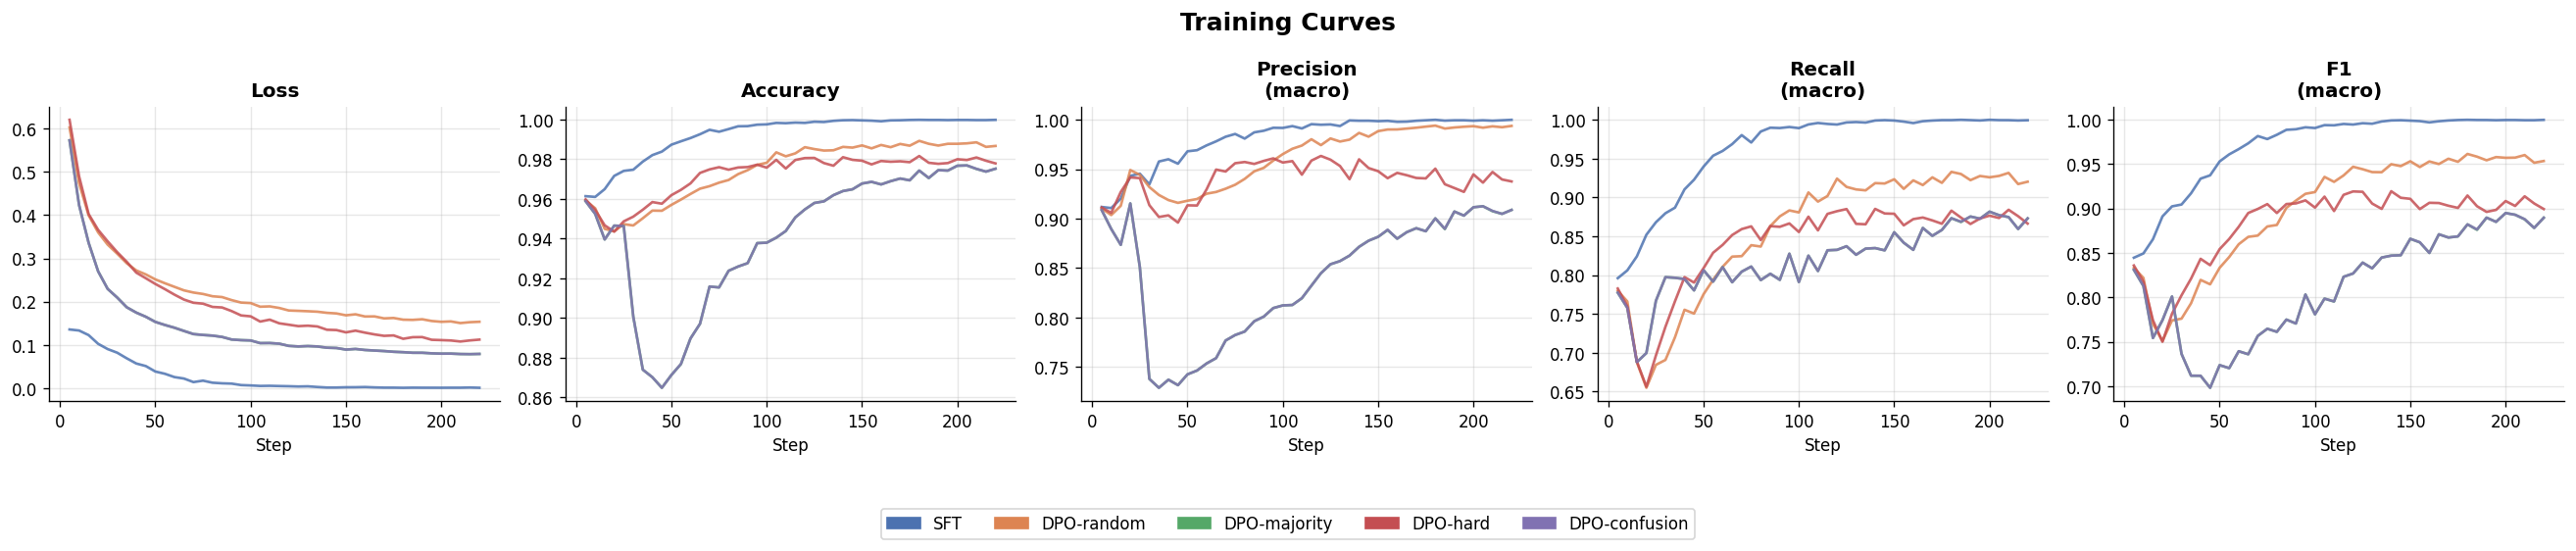

In [14]:
TRAIN_METRICS = ['loss', 'accuracy', 'precision', 'recall', 'f1']
TRAIN_LABELS  = ['Loss', 'Accuracy', 'Precision\n(macro)', 'Recall\n(macro)', 'F1\n(macro)']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, metric, label in zip(axes, TRAIN_METRICS, TRAIN_LABELS):
    for run_name, log_dir in RUNS.items():
        # SFT logs 'train/loss'; DPO variants log 'train/dpo_loss'
        if metric == 'loss':
            tag = 'train/loss' if run_name == 'SFT' else 'train/dpo_loss'
        else:
            tag = f'train/{metric}'
        steps, values = load_scalars(log_dir, tag)
        ax.plot(steps, values, color=COLORS[run_name], alpha=0.85,
                linewidth=1.6, label=run_name)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Step')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # if metric != 'loss':
    #     ax.set_ylim(-0.05, 1.05)
    # else:
    #     ax.set_ylabel('Loss (CE for SFT, DPO for others)', fontsize=8)

fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.16), fontsize=10, frameon=True)
fig.suptitle('Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RUNS_DIR}/training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

* In terms of accuracy, we can see that SFT converges to 1.0, while it's not the case for the DPO variants. This means that DPO variants are less prone to overfitting than SFT.
* In other metrics as well (precision, recall) SFT still achieves a perfect score, another possible sign of overfitting.
* There is a big drop in performance, before the curves catch up again for DPO. One of the possible explanations is that since the negative class correspond to the majority class in most cases, the model first learns to penalize this class which results in worse overall metrics, before learning to recover from that.

### 3.2 Validation Curves

Validation is run once per epoch (`VAL_EVERY = 1`) using the **full training set
as the in-context context** and the held-out validation split as query samples.
This mirrors the actual inference pattern of TabICL and gives a fair epoch-level
estimate of generalisation.  All five metrics share the same scale and are directly
comparable across methods.

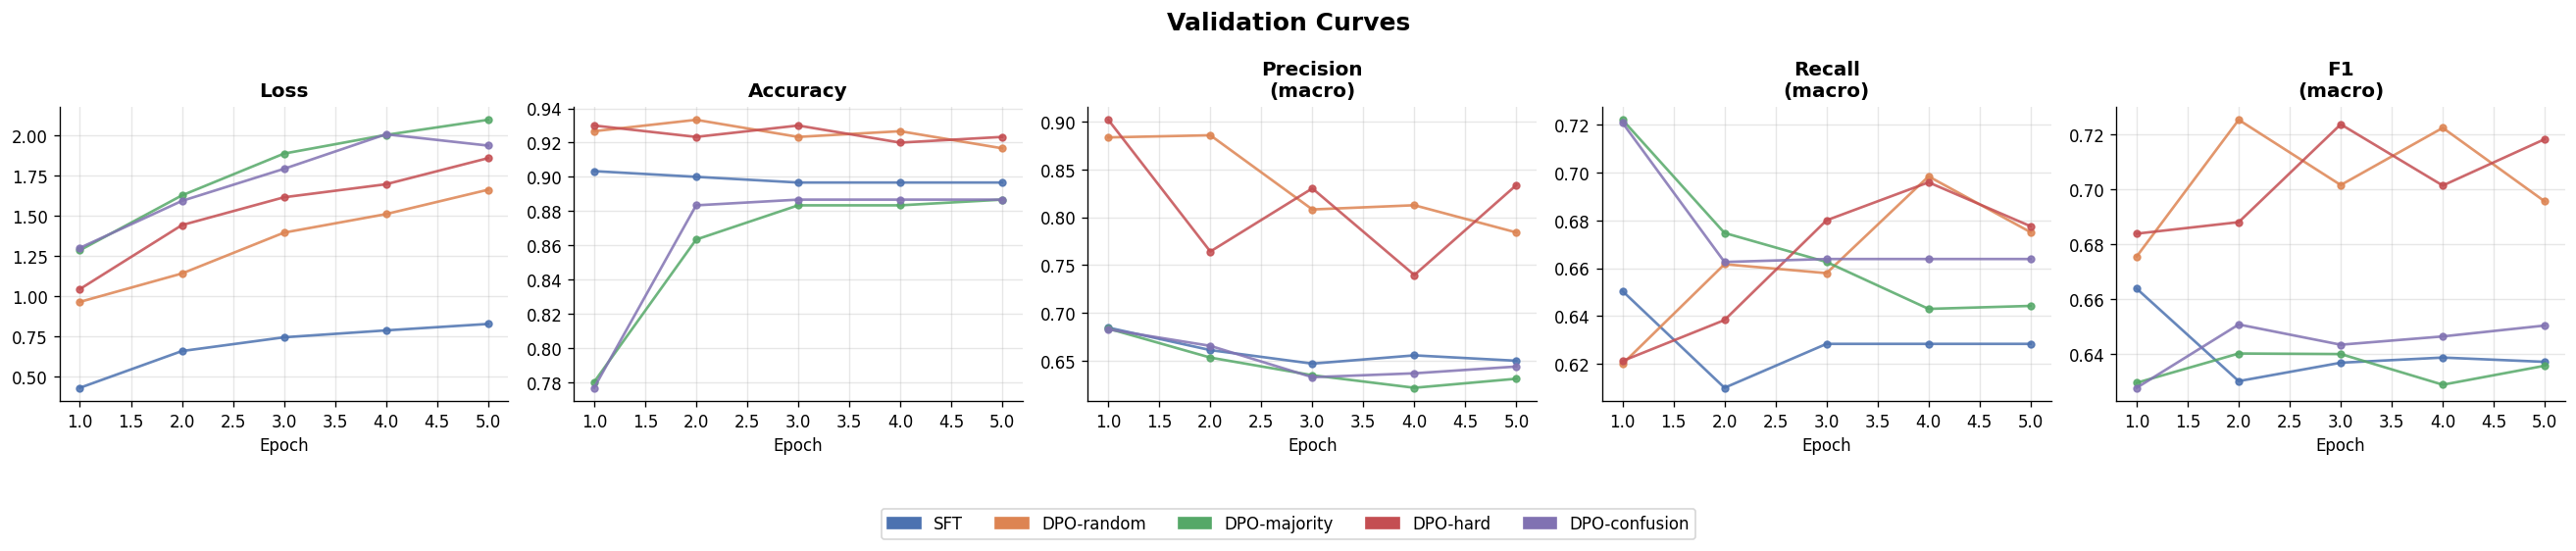

In [15]:
VAL_METRICS = ['loss', 'accuracy', 'precision', 'recall', 'f1']
VAL_LABELS  = ['Loss', 'Accuracy', 'Precision\n(macro)', 'Recall\n(macro)', 'F1\n(macro)']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, metric, label in zip(axes, VAL_METRICS, VAL_LABELS):
    for run_name, log_dir in RUNS.items():
        steps, values = load_scalars(log_dir, f'val/{metric}')
        ax.plot(steps, values, color=COLORS[run_name], alpha=0.85,
                linewidth=1.6, marker='o', markersize=4, label=run_name)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # if metric != 'loss':
    #     ax.set_ylim(-0.05, 1.05)

fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.16), fontsize=10, frameon=True)
fig.suptitle('Validation Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RUNS_DIR}/validation_curves.png', bbox_inches='tight', dpi=150)
plt.show()

* In terms of cross-entropy loss, SFT naturally achieves a better level than DPO.
* However, some DPO variants (random negatives, and hard negatives) achieve significantly better precision, recall, and thus f1 score.
* This suggests that DPO is useful in combatting the imbalanced aspect of the data considered for this problem.
* From the validation curves, there is no clear sign of over-fitting as no curve is really degrading, except maybe DPO with majority class negatives and confusion-based negatives in the recall metric.

### 4.3 Test Evaluation

We evaluate **seven models** on the held-out test set using the dataset that was saved
by `make_data.py` at the beginning of this notebook:

- **Vanilla TabICL** — the pretrained checkpoint with no fine-tuning, used as a
  zero-shot in-context baseline.
- **Neuralk NICL** — a competing pretrained tabular foundation model, evaluated
  via its scikit-learn-compatible `NICLClassifier` interface.
- **SFT / DPO variants** — the five fine-tuned checkpoints produced above.

The fine-tuned models use the full training split as in-context examples; vanilla
TabICL and Neuralk NICL do the same through their `fit` / `predict` interface.

In [17]:
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, classification_report
)
from tabicl import TabICL, TabICLClassifier
from neuralk import NICLClassifier
from tabicl.finetune.utils import evaluate

# ── Load dataset saved by make_data.py ───────────────────────────────────────
data = np.load(DATASET_PATH)
X_train, y_train = data['X_train'], data['y_train']
X_val,   y_val   = data['X_val'],   data['y_val']
X_test,  y_test  = data['X_test'],  data['y_test']
print(f'Dataset — train: {len(y_train)}, val: {len(y_val)}, test: {len(y_test)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Helper: evaluate a sklearn-style model ───────────────────────────────────
def eval_sklearn(preds):
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro', zero_division=0)
    rec  = recall_score(y_test, preds, average='macro', zero_division=0)
    f1   = f1_score(y_test, preds, average='macro', zero_division=0)
    print('Classification report:\n', classification_report(y_test, preds, zero_division=0))
    print(f'  acc={acc:.4f}  prec={prec:.4f}  rec={rec:.4f}  f1={f1:.4f}')
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

test_results = {}

# ── Vanilla TabICL (pretrained, no fine-tuning) ───────────────────────────────
print()
print('=' * 60)
print('  Evaluating: Vanilla TabICL')
print('=' * 60)
tabicl_clf = TabICLClassifier()
tabicl_clf.fit(X_train, y_train)
test_results['Vanilla TabICL'] = eval_sklearn(tabicl_clf.predict(X_test))

# ── Neuralk NICLClassifier ────────────────────────────────────────────────────
print()
print('=' * 60)
print('  Evaluating: Neuralk NICL')
print('=' * 60)
nicl_clf = NICLClassifier()
nicl_clf.fit(X_train, y_train)
test_results['Neuralk NICL'] = eval_sklearn(nicl_clf.predict(X_test))

# ── Fine-tuned checkpoints ────────────────────────────────────────────────────
CKPT_PATHS = {
    'SFT':           f'{RUNS_DIR}/sft/tabicl_sft.ckpt',
    'DPO-random':    f'{RUNS_DIR}/dpo_random/tabicl_dpo.ckpt',
    'DPO-majority':  f'{RUNS_DIR}/dpo_majority/tabicl_dpo.ckpt',
    'DPO-hard':      f'{RUNS_DIR}/dpo_hard/tabicl_dpo.ckpt',
    'DPO-confusion': f'{RUNS_DIR}/dpo_confusion/tabicl_dpo.ckpt',
}

for run_name, ckpt_path in CKPT_PATHS.items():
    print()
    print('=' * 60)
    print(f'  Evaluating: {run_name}')
    print('=' * 60)
    ckpt  = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    model = TabICL(**ckpt['config'])
    model.load_state_dict(ckpt['state_dict'])
    model = model.to(device)
    loss, acc, prec, rec, f1 = evaluate(
        model, X_train, y_train, X_test, y_test, device
    )
    test_results[run_name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1
    }
    print(f'  acc={acc:.4f}  prec={prec:.4f}  rec={rec:.4f}  f1={f1:.4f}')

print()
print('All evaluations complete.')

Dataset — train: 1400, val: 300, test: 300
Device: cuda

  Evaluating: Vanilla TabICL
Classification report:
               precision    recall  f1-score   support

           0       0.73      0.69      0.71        16
           1       0.78      0.44      0.56        16
           2       0.96      0.99      0.97       268

    accuracy                           0.94       300
   macro avg       0.82      0.70      0.75       300
weighted avg       0.94      0.94      0.93       300

  acc=0.9400  prec=0.8225  rec=0.7034  f1=0.7468

  Evaluating: Neuralk NICL
Classification report:
               precision    recall  f1-score   support

           0       0.77      0.62      0.69        16
           1       1.00      0.38      0.55        16
           2       0.95      0.99      0.97       268

    accuracy                           0.94       300
   macro avg       0.91      0.66      0.73       300
weighted avg       0.94      0.94      0.93       300

  acc=0.9400  prec=0.9053  

### 4.4 Test Performance — Bar Chart Comparison

The bar charts below summarise test-set performance of all **seven models** across
all four classification metrics.  The two pretrained baselines (Vanilla TabICL and
Neuralk NICL) appear first, followed by the five fine-tuned runs.

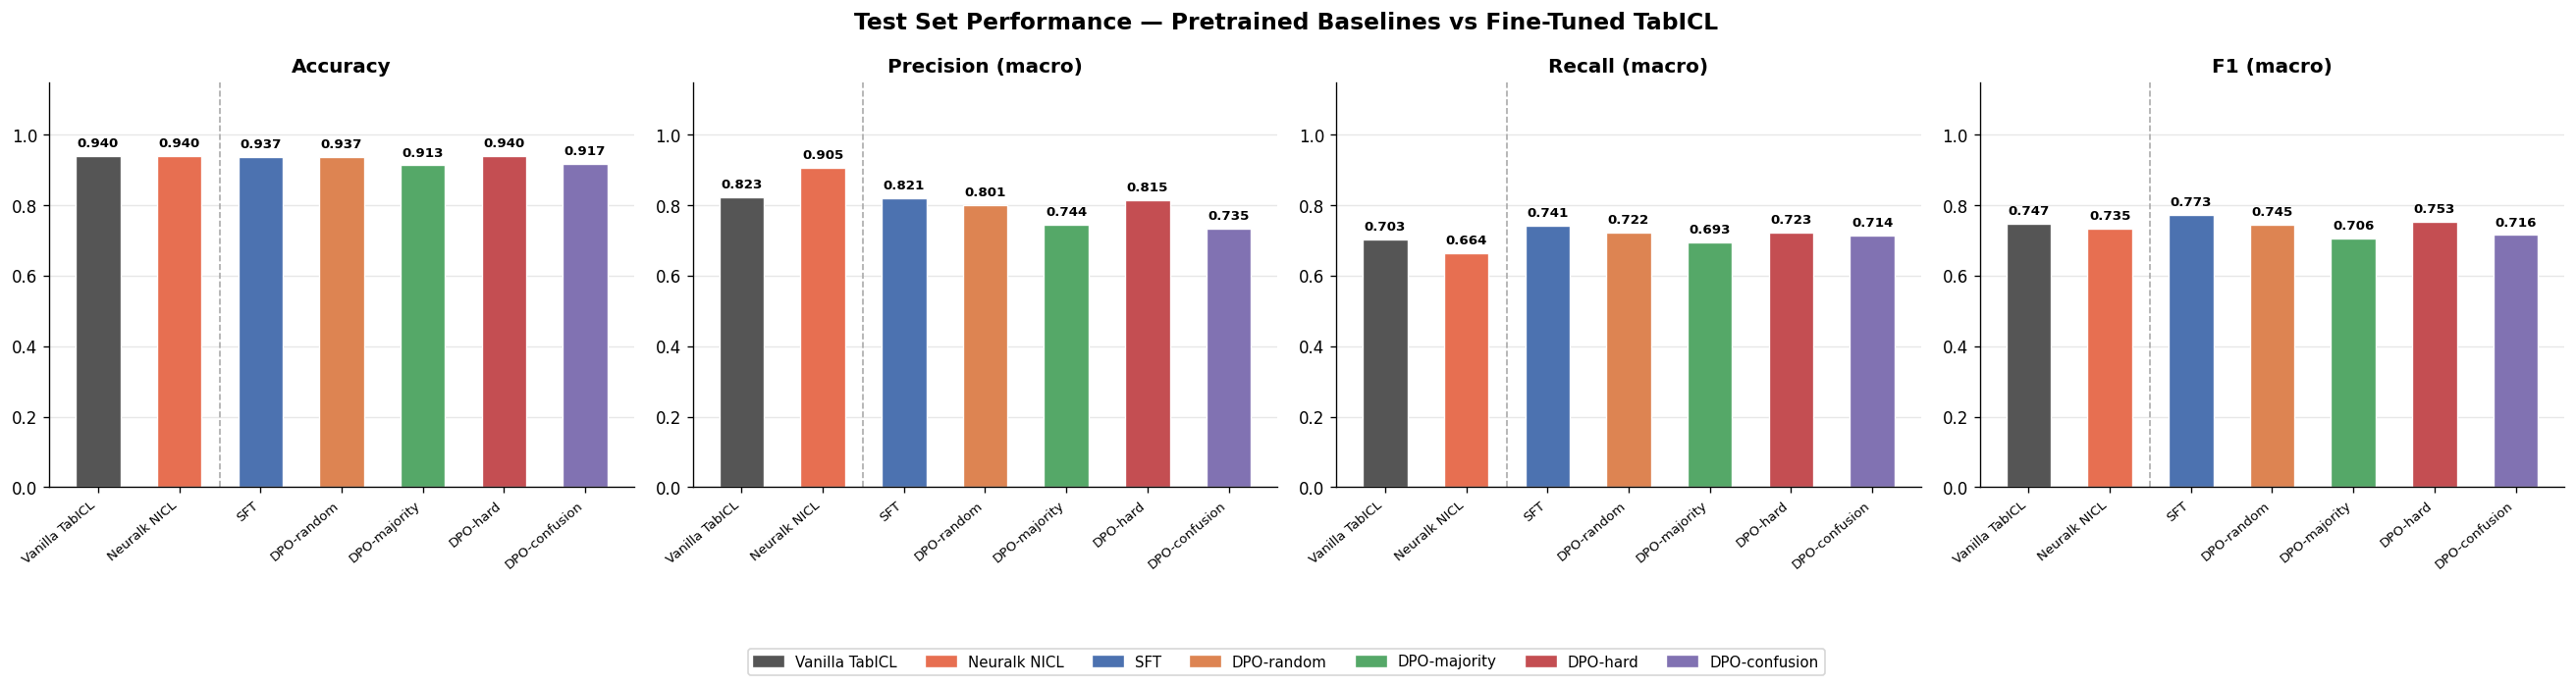

In [18]:
BAR_METRICS = ['accuracy', 'precision', 'recall', 'f1']
BAR_LABELS  = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']

run_names  = list(ALL_COLORS.keys())
bar_colors = [ALL_COLORS[r] for r in run_names]
x          = np.arange(len(run_names))
bar_width  = 0.55

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, metric, label in zip(axes, BAR_METRICS, BAR_LABELS):
    values = [test_results.get(r, {}).get(metric, 0.0) for r in run_names]
    bars   = ax.bar(x, values, width=bar_width, color=bar_colors,
                    edgecolor='white', linewidth=0.8)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(run_names, rotation=40, ha='right', fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Add a vertical separator after the two pretrained baselines
    ax.axvline(x=1.5, color='#aaaaaa', linewidth=1.0, linestyle='--')
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.018,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold',
        )

fig.suptitle(
    'Test Set Performance — Pretrained Baselines vs Fine-Tuned TabICL',
    fontsize=14, fontweight='bold',
)
all_legend_handles = [
    mpatches.Patch(color=c, label=n) for n, c in ALL_COLORS.items()
]
fig.legend(handles=all_legend_handles, loc='lower center', ncol=7,
           bbox_to_anchor=(0.5, -0.16), fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig(f'{RUNS_DIR}/test_barplots.png', bbox_inches='tight', dpi=150)
plt.show()

* On the test set however, there is no clear advantage of using DPO variants.
* In terms of accuracy, all methods appear to have sacrifised accuracy, except the DPO hard variant which in the same level as pretrained TabICL and NICL.
* In terms of precision, NICL has the absolute best performance followed by vanilla TabICL.
* As expected, the recall is where we see the most improvement from the finetuned variants, which surprisingly comes from the SFT version, followed by DPO with hard negatives.
* We conclude that there is no clear winner in the current experimental setup. However, there are multiple limitations that might be at the cause of this observations. We mention some of these limitations in the next cell.


### Limitations and suggested improvements

* First of all, the experimental setup slightly changes between training, validation and test, which can be problematic. The reason behind this is that the context / query during training are sampled randomly, while the full training dataset is used during validation and test.
    * A possible solution would be to generate multiple datasets for training, then test on new unseen ones with similar characteristics (class weights).
* Given that we generated small datasets, the size of the validation and test sets is small and the reported scores might be noisy.
    * The experiments have to be repeated multiple times with different random seeds and reporting the scores with confidence intervals.
* I didn't do hyperparameters optimization for DPO, just went with some defaults that seemed plausible.
* Full finetuning is probably not the best approach to retrain most of the model's prior. 

---
## 5. Summary

This notebook showed how DPO-based fine-tuning can be applied to TabICL to improve
performance on imbalanced tabular classification, and benchmarked it against
pretrained baselines.

### Thank you!
* By: Abdelhakim Benechehab